# **IBM Data Science Professional Certificate Capstone Project**


##Exploring and Preparing Data


We will perform EDA and data Feature Engineering.


### Import Libraries and Define Auxiliary Functions


In [1]:
import piplite
await piplite.install(['numpy'])
await piplite.install(['pandas'])
await piplite.install(['seaborn'])

In [ ]:
# pandas is a library for data manipulation and analysis.
import pandas as pd
#NumPy is a library that supports large, multi-dimensional arrays and matrices
import numpy as np
# Matplotlib is a library to plot data.
import matplotlib.pyplot as plt
#Seaborn is a data visualization library based on matplotlib.
import seaborn as sns

## Exploratory Data Analysis

First, let's read the SpaceX dataset into a Pandas dataframe and print its summary


In [3]:
from js import fetch
import io

URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv"
resp = await fetch(URL)
dataset_part_2_csv = io.BytesIO((await resp.arrayBuffer()).to_py())
df=pd.read_csv(dataset_part_2_csv)
df.head(5)

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0



We can plot out the <code>FlightNumber</code> vs. <code>PayloadMass</code>and overlay the outcome of the launch. We see that as the flight number increases, the first stage is more likely to land successfully. The payload mass is also important; it seems the more massive the payload, the less likely the first stage will return.

### Step 1

We visualize the relationship between Flight Number and Launch Site. As the flights number increases there seem to be more successes for all launch sites.

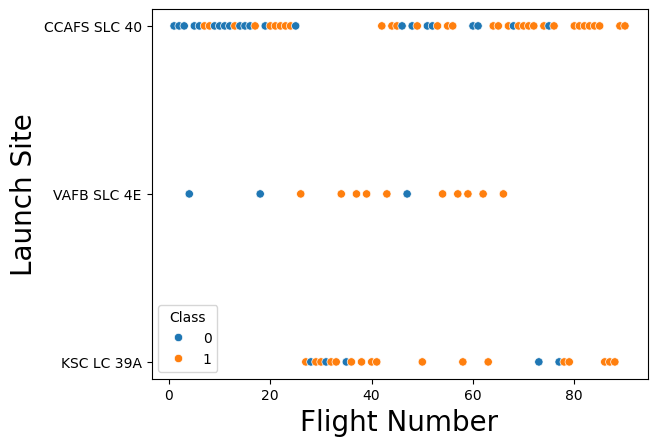

In [ ]:
#  Scatter point chart with x axis to be Flight Number and y axis to be the launch site, and hue to be the class value

sns.scatterplot(y="LaunchSite", x="FlightNumber", hue="Class", data=df)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

## Step 2

We also want to observe if there is any relationship between launch sites and their payload mass.


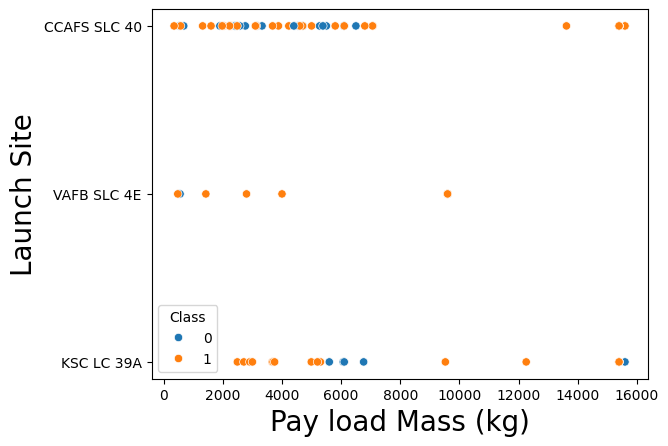

In [12]:
# Plot a scatter point chart with x axis to be Pay Load Mass (kg) and y axis to be the launch site, and hue to be the class value
sns.scatterplot(y="LaunchSite", x="PayloadMass", hue="Class", data=df)
plt.xlabel("Pay load Mass (kg)",fontsize=20)
plt.ylabel("Launch Site",fontsize=20)
plt.show()

The VAFB-SLC launchsite shows no rockets launched for heavypayload mass (greater than 10000).


### Step 3

We want to know if there is a relationship between success rate and orbit type.

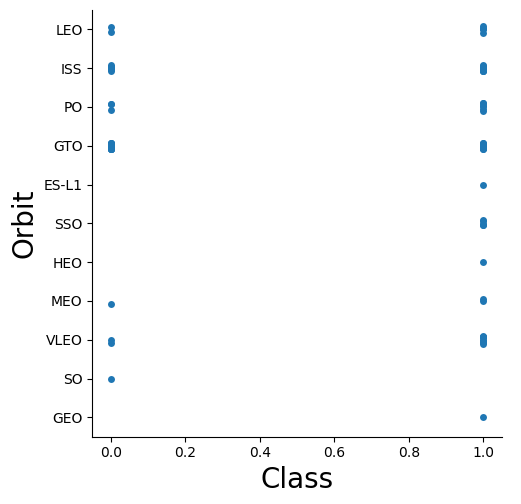

In [ ]:
# Visualize the relationship between success rate of each orbit type
sns.catplot(y="Orbit", x="Class", data=df)
plt.xlabel("Class",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

Let's create a `bar chart` for the sucess rate of each orbit


In [ ]:
# Use groupby method on Orbit column and get the mean of Class column
orbitrate = df.groupby("Orbit").mean("Class")
orbitrate.drop(["FlightNumber","PayloadMass","Flights","GridFins","Reused","Legs","Block","ReusedCount","Longitude","Latitude"], axis=1, inplace=True)
orbitrate

,Class
Orbit,
ES-L1,1.000000
GEO,1.000000
GTO,0.518519
HEO,1.000000
ISS,0.619048
LEO,0.714286
MEO,0.666667
PO,0.666667
SO,0.000000


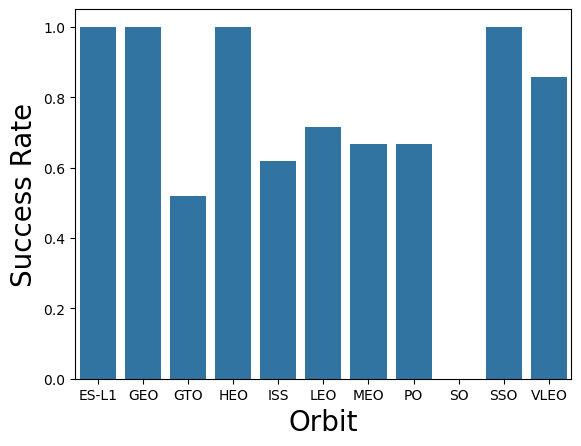

In [ ]:
# Create the barplot for Orbit vs Class
sns.barplot(y="Class", x="Orbit", data=orbitrate)
plt.xlabel("Orbit",fontsize=20)
plt.ylabel("Success Rate",fontsize=20)
plt.show()

Orbits ES-L1, GEO, HEO and SSO have the highest average success rate (1).

### Step 4

For each orbit, we want to see if there is any relationship between FlightNumber and Orbit type.


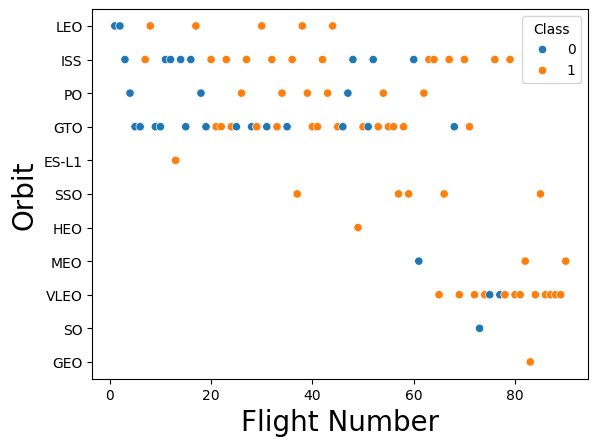

In [ ]:
# Scatter point chart with x axis as FlightNumber and y axis as the Orbit, and hue to be the class value
sns.scatterplot(y="Orbit", x="FlightNumber", hue="Class", data=df)
plt.xlabel("Flight Number",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

In the LEO orbit, success appears related to the number of flights; on the other hand, there seems to be no relationship between flight number and success when in GTO orbit.


### Step 5

Similarly, we can plot the Payload vs. Orbit scatter plot to reveal the relationship between Payload and Orbit type


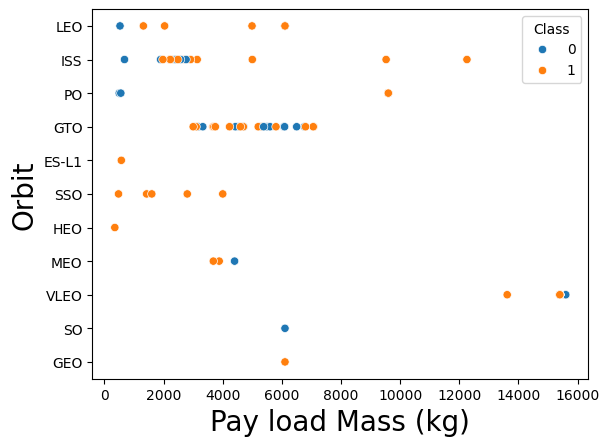

In [ ]:
# Scatter point chart with x axis as Payload and y axis as Orbit, and hue to be the class value
sns.scatterplot(y="Orbit", x="PayloadMass", hue="Class", data=df)
plt.xlabel("Pay load Mass (kg)",fontsize=20)
plt.ylabel("Orbit",fontsize=20)
plt.show()

For PO, LEO and ISS orbits, the heavier payloads had successfuls landings. 

However for GTO, both positive and negative landing rates don't seem to be correlated to payload mass.

### Step 6

We visualize the average success yearly trend. 

In [ ]:
# Function to extract years from date 
year=[] # Creates an empty list to hold the years
def Extract_year():
    for i in df["Date"]:
        year.append(i.split("-")[0]) # Splits the string at the hyphens and takes the first part (the year), then appends it to the year list
    return year # Returns the completed list of years

Extract_year() # Runs the function so the list gets filled

df['Date'] = year # Replaces the entire Date column with the extracted years

df.head()
    

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [ ]:
yearrate = df.groupby("Date").mean("Class") # Groups the data by the Date column (which now contains only years) and calculates the mean of the Class column for each year
yearrate.drop(["FlightNumber","PayloadMass","Flights","GridFins","Reused","Legs","Block","ReusedCount","Longitude","Latitude"], axis=1, inplace=True)
yearrate

,Class
Date,
2010,0.000000
2012,0.000000
2013,0.000000
2014,0.333333
2015,0.333333
2016,0.625000
2017,0.833333
2018,0.611111
2019,0.900000


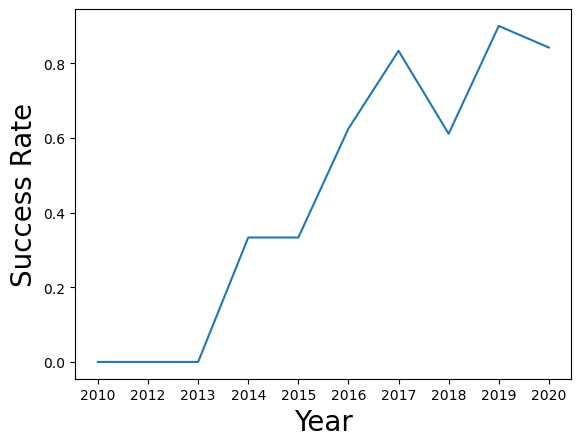

In [ ]:
# Plot of line chart with x axis as the extracted year and y axis as the success rate
sns.lineplot(y="Class", x="Date", data=yearrate)
plt.xlabel("Year",fontsize=20)
plt.ylabel("Success Rate",fontsize=20)
plt.show()

 The sucess rate have been increasing from 2013 through 2020.

## Feature Engineering

We will select the features that will be used in success prediction.

In [34]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


### Step 7

We use the function <code>get_dummies</code> to apply OneHotEncoder to the column <code>Orbits</code>, <code>LaunchSite</code>, <code>LandingPad</code>, and <code>Serial</code>. The resulting dataframe includes all features including the encoded ones.

In [ ]:
# get_dummies() function to create dummy variables for categorical columns
features_one_hot=pd.get_dummies(features, columns=["Orbit", "LaunchSite", "LandingPad", "Serial"])
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,525.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,3,677.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,500.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,3170.000000,1,False,False,False,1.0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Step 8

Now that our <code>features_one_hot</code> dataframe only contains numbers, we cast the entire dataframe to variable type <code>float64</code>


In [ ]:
# astype function to convert data types of the columns to float64
features_one_hot = features_one_hot.astype("float64")

In [47]:
features_one_hot.dtypes

FlightNumber    float64
PayloadMass     float64
Flights         float64
GridFins        float64
Reused          float64
                 ...   
Serial_B1056    float64
Serial_B1058    float64
Serial_B1059    float64
Serial_B1060    float64
Serial_B1062    float64
Length: 80, dtype: object

In [48]:
features_one_hot.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1.0,6104.959412,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2.0,525.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,3.0,677.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,4.0,500.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5.0,3170.000000,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


We export the dataframe as a <b>CSV</b> file.

In [49]:
features_one_hot.to_csv('dataset_part\_3.csv', index=False)